In [47]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from category_encoders import TargetEncoder


In [48]:
df = pd.read_csv("idealista/data/Datos.csv")

EXPLORACIÓN BASICA


In [49]:
df.shape

(11826, 14)

In [50]:
df.head()

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


In [51]:
df.describe()

,PrecioActual,PrecioAnterior,metros,habitaciones,baños
count,1.182600e+04,1.182600e+04,11826.000000,11460.000000,11826.000000
mean,1.030501e+06,7.359704e+04,153.790039,2.847731,0.394047
std,1.237718e+06,3.639753e+05,766.217750,1.432402,0.882134
min,1.200000e+04,0.000000e+00,11.000000,1.000000,0.000000
25%,2.890000e+05,0.000000e+00,68.000000,2.000000,0.000000
50%,6.200000e+05,0.000000e+00,103.000000,3.000000,0.000000
75%,1.329000e+06,0.000000e+00,160.000000,3.000000,0.000000
max,2.300000e+07,8.450000e+06,75000.000000,20.000000,7.000000


In [52]:
df.columns


Index(['provincia', 'zona', 'titulo', 'PrecioActual', 'PrecioAnterior',
       'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta', 'baños',
       'tags', 'descripcion', 'Enlace'],
      dtype='str')

VER QUE TIPO DE DATOS

In [53]:
df.dtypes

provincia             str
zona                  str
titulo                str
PrecioActual        int64
PrecioAnterior      int64
metros              int64
habitaciones      float64
ascensor              str
localizacion          str
planta                str
baños               int64
tags                  str
descripcion           str
Enlace                str
dtype: object

In [54]:
df.dtypes[df.dtypes != 'str']

PrecioActual        int64
PrecioAnterior      int64
metros              int64
habitaciones      float64
baños               int64
dtype: object

In [55]:
df.select_dtypes(include=['object', 'string'])

,provincia,zona,titulo,ascensor,localizacion,planta,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",S,EXTERIOR,5ª,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",N,EXTERIOR,1ª,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",S,NaN,2ª,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",S,INTERIOR,BAJO,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",S,EXTERIOR,2ª,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/
...,...,...,...,...,...,...,...,...,...
11821,madrid,centro,"Piso en calle del Amparo, Lavapiés-Embajadores...",N,INTERIOR,BAJO,"PISO,INMOBILIARIA,HOGAR,NUEVO",¡Descubre tu nuevo hogar en el corazón de Madr...,https://www.idealista.com/inmueble/107292488/
11822,madrid,centro,"Piso en calle Gran Vía, Chueca-Justicia, Madrid",S,EXTERIOR,2ª,"PISO,LUJO,EXCLUSIVO,EXTERIOR",Piso totalmente exterior ubicado entre el barr...,https://www.idealista.com/inmueble/103878128/
11823,madrid,tetuan,"Piso en calle del Capitán Blanco Argibay, Vald...",S,EXTERIOR,BAJO,"APARTAMENTO,METRO",¡IDEAL INVERSORES! Precioso apartamento en Val...,https://www.idealista.com/inmueble/107025446/
11824,madrid,carabanchel,"Piso en calle de Aceuchal, Vista Alegre, Madrid",N,EXTERIOR,2ª,"OPORTUNIDAD,METRO","**IDEAL INVERSORES, NO DEJES PASAR ESTA OPORTU...",https://www.idealista.com/inmueble/106946149/


BUSCAR CORRELACION COL NUMERICAS  CON VARIABLE OBJETIVO

In [56]:
corr_precio =  df.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').abs().sort_values(ascending=False)
print(corr_precio)

habitaciones      0.504158
metros            0.130661
PrecioAnterior    0.120442
baños             0.048852
Name: PrecioActual, dtype: float64


BUSCAR CORRELACION CON COL ZONA CONTRA LA VARIABLE OBJETIVO

In [57]:
#HACER DUMMIES

df_dummies_zona = pd.get_dummies(df, columns=[ 'zona'], dtype=int)
print(df_dummies_zona.shape)


(11826, 34)


In [58]:
corr_precio =  df_dummies_zona.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').abs().sort_values(ascending=False)
print(corr_precio)

habitaciones                0.504158
zona_barrio-de-salamanca    0.343149
zona_chamartin              0.149966
zona_puente-de-vallecas     0.146294
zona_carabanchel            0.137341
metros                      0.130661
PrecioAnterior              0.120442
zona_villaverde             0.111005
zona_moncloa                0.108327
zona_usera                  0.101781
zona_chamberi               0.101545
zona_latina                 0.100268
zona_san-blas               0.086840
zona_ciudad-lineal          0.086012
zona_tetuan                 0.084333
zona_arganzuela             0.081077
zona_villa-de-vallecas      0.079941
zona_vicalvaro              0.070111
zona_centro                 0.059270
zona_moratalaz              0.053912
baños                       0.048852
zona_retiro                 0.047870
zona_barajas                0.034893
zona_hortaleza              0.025573
zona_fuencarral             0.020662
Name: PrecioActual, dtype: float64


DIAGRAMA DE DISPERSIÓN -->  impacto directo en la variable objetivo. Y buscar los valores atípicos



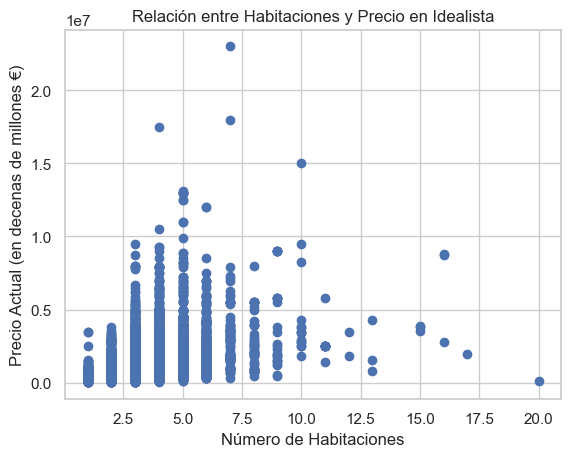

In [59]:

plt.scatter(x='habitaciones', y='PrecioActual', data=df)

# Título para el eje X
plt.xlabel('Número de Habitaciones')
# Título para el eje Y
plt.ylabel('Precio Actual (en decenas de millones €)')
# Título principal del gráfico
plt.title('Relación entre Habitaciones y Precio en Idealista')

# Para que se visualice correctamente
plt.show()


In [60]:
df.query('PrecioActual > 12000000')

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
1914,madrid,barrio-de-salamanca,"Dúplex en plaza Marqués de Salamanca, 11, List...",13090000,0,605,5.0,S,EXTERIOR,6ª,0,"VIVIENDA,TERRAZA,ÁTICO,PISCINA,EXTERIOR",Ático con piscina en venta en Plaza Marqués de...,https://www.idealista.com/inmueble/101733694/
4462,madrid,barrio-de-salamanca,"Piso en Castellana, Madrid",12500000,0,570,5.0,S,EXTERIOR,6ª,0,"VIVIENDA,ÁTICO,INMOBILIARIA,HALL,IMPRESIONANTE","Álvora Capital Properties, consultora inmobili...",https://www.idealista.com/inmueble/103340602/
4684,madrid,chamberi,"Piso en Almagro, Madrid",12500000,0,750,5.0,S,EXTERIOR,2ª,0,"PISO,TERRAZA,VISTAS,EXCLUSIVO,INTERIOR",Olisson Club ofrece este exclusivo piso con un...,https://www.idealista.com/inmueble/107074597/
5735,madrid,chamartin,"Ático en El Viso, Madrid",17500000,0,697,4.0,S,EXTERIOR,8ª,0,"VIVIENDA,ÁTICO,INTERIOR",Esta vivienda se concibe como un proyecto en e...,https://www.idealista.com/inmueble/106795928/
6191,madrid,barrio-de-salamanca,"Piso en calle de Velázquez, Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,REFORMADO,LUJO,ELECTRODOMÉSTICOS...",Olivares Consultores vende esta vivienda de lu...,https://www.idealista.com/inmueble/106652699/
6489,madrid,chamartin,Casa o chalet independiente en calle de Castel...,23000000,0,1000,7.0,NaN,NaN,NaN,0,CASA,Lucía Suárez-Zuloaga de GV | EL VISO comercial...,https://www.idealista.com/inmueble/107095805/
6546,madrid,barrio-de-salamanca,"Piso en calle Velázquez, Recoletos, Madrid",13000000,0,425,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,INMOBILIARIA","Álvora Capital Properties, consultora inmobili...",https://www.idealista.com/inmueble/107166409/
7522,madrid,barrio-de-salamanca,"Piso en calle Velázquez, Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,LUJO,ESPECTACULAR,EXCLUSIVO,INMO...",REA Inmobiliaria presenta este exclusivo piso ...,https://www.idealista.com/inmueble/107212046/
7614,madrid,barrio-de-salamanca,"Piso en Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,EXCLUSIVA,LUJO,ESPECTACULAR,FINC...",Presentamos esta espectacular y exclusiva vivi...,https://www.idealista.com/inmueble/107165396/
9675,madrid,barrio-de-salamanca,"Piso en Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,REFORMADO,EXCLUSIVA,LUJO,ESPECTA...",Olisson Club pone a su disposición esta espect...,https://www.idealista.com/inmueble/106771279/


In [61]:
df.query('habitaciones > 10.0')

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
40,madrid,san-blas,"Piso en avenida de Hellín, Hellín, Madrid",128000,0,59,20.0,N,EXTERIOR,BAJO,0,"VIVIENDA,FINCA",Especial Inversores. Se vende ALQUILADO A TERC...,https://www.idealista.com/inmueble/106562409/
122,madrid,moncloa,Casa o chalet independiente en avenida Osa May...,2750000,0,1240,16.0,NaN,NaN,NaN,0,"VISTAS,ESTRENAR,PISCINA,GARAJE,NUEVO","Fantástico unifamiliar, con excelentes vistas ...",https://www.idealista.com/inmueble/106030032/
280,madrid,moncloa,"Piso en Casa de Campo, Madrid",3900000,0,1139,15.0,S,EXTERIOR,NaN,0,"VIVIENDA,PISCINA,CASA,APARTAMENTO,JARDÍN",Apartamento con jardín y piscina privada en el...,https://www.idealista.com/inmueble/107161264/
747,madrid,moncloa,"Casa o chalet independiente en Valdemarín, Madrid",2500000,0,500,11.0,NaN,NaN,NaN,6,"CHALET,PISCINA,CASA,PARCELA",Valdemarín: chalet independiente en 1 sola pla...,https://www.idealista.com/inmueble/103148614/
2574,madrid,moncloa,"Casa o chalet independiente en Valdemarín, Madrid",2500000,0,761,11.0,NaN,NaN,NaN,0,"VIVIENDA,CASA,PARCELA",Berkshire Hathaway le presenta una propiedad ...,https://www.idealista.com/inmueble/104104880/
3266,madrid,moncloa,"Casa o chalet independiente en Valdemarín, Madrid",2500000,0,761,11.0,NaN,NaN,NaN,0,"VIVIENDA,FINCA,PISCINA,PARCELA",De Salas Consultores Inmobiliarios les ofrece ...,https://www.idealista.com/inmueble/104137170/
3471,madrid,chamartin,"Casa o chalet independiente en El Viso, Madrid",8700000,0,1000,16.0,NaN,NaN,NaN,0,"CASA,JARDÍN,PARCELA,METRO,EXTERIOR",Lucía Suárez-Zuloaga de GV | EL VISO comercial...,https://www.idealista.com/inmueble/106199832/
3866,madrid,puente-de-vallecas,"Piso en San Diego, Madrid",780000,0,443,13.0,N,EXTERIOR,1ª,0,"PISO,OPORTUNIDAD",SE VENDE LOTE DE 5 PISOS Y 2 LOCALES EN EL MIS...,https://www.idealista.com/inmueble/104021836/
3995,madrid,chamartin,"Chalet en El Viso, Madrid",5800000,0,910,11.0,NaN,NaN,NaN,0,"AMPLIO,PISCINA,CASA,JARDÍN,PARCELA",Fantástica casa independiente en la mejor zona...,https://www.idealista.com/inmueble/101777951/
4538,madrid,chamberi,"Piso en Gaztambide, Madrid",1580000,0,317,13.0,S,EXTERIOR,1ª,0,"VIVIENDA,PISO,AMPLIO,METRO",Ana Bareño de GV | CHAMBERÍ comercializa el si...,https://www.idealista.com/inmueble/106291867/


ELIMINAR OUTLINERS DE HABITACIONES VS PRECIO

In [62]:
# Mantenemos solo las casas que están por debajo de 13.5 millones y tienen menos de 14 habitaciones
df = df.query('PrecioActual < 12000000 and habitaciones < 10')

# Comprobamos cuántas casas han quedado
print(f"Outliers eliminados. Nos quedan {df.shape[0]} pisos.")

Outliers eliminados. Nos quedan 11409 pisos.


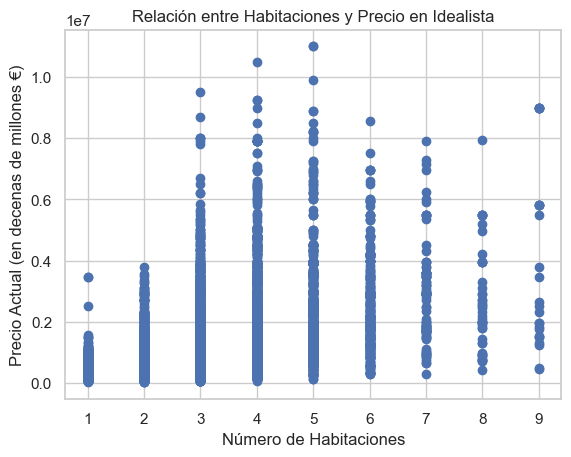

In [63]:

plt.scatter(x='habitaciones', y='PrecioActual', data=df)

# Título para el eje X
plt.xlabel('Número de Habitaciones')
# Título para el eje Y
plt.ylabel('Precio Actual (en decenas de millones €)')
# Título principal del gráfico
plt.title('Relación entre Habitaciones y Precio en Idealista')

# Para que se visualice correctamente
plt.show()


In [64]:
#3058, 341,6035, 7958, 9120, 9434, 7424, 1039, 4847, 8789, 10970, 171, 5314
df.query('habitaciones == 1 and PrecioActual > 2000000')


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
827,madrid,moncloa,"Piso en Argüelles, Madrid",3450000,0,780,1.0,S,EXTERIOR,NaN,0,VIVIENDA,Propiedad segregable junto a Plaza de EspañaEn...,https://www.idealista.com/inmueble/105328699/
10277,madrid,moncloa,"Piso en plaza de José Moreno Villa, Argüelles,...",3450000,0,784,1.0,S,EXTERIOR,1ª,0,"VIVIENDA,OPORTUNIDAD",Ana Gómez de la Serna de GV | ROSALES comercia...,https://www.idealista.com/inmueble/105896708/
11404,madrid,barrio-de-salamanca,"Ático en Recoletos, Madrid",2500000,0,140,1.0,S,EXTERIOR,3ª,0,"VIVIENDA,TERRAZA,EXCLUSIVA,LUJO,REFORMADA,PARQ...","Exclusiva y singular vivienda en venta, se tra...",https://www.idealista.com/inmueble/106011753/


In [65]:
#FILAS A ELIMINAR
# Lista exacta de los índices que quieres borrar
filas_a_borrar = [3058, 341, 6035, 7958, 9120, 9434, 7424, 1039, 4847, 8789, 10970, 171, 5314]

# Le decimos a Pandas que elimine esas filas y actualice el DataFrame
df = df.drop(filas_a_borrar)

# Comprobamos el resultado
print(f"Las {len(filas_a_borrar)} filas han sido eliminadas. Ahora tienes {df.shape[0]} pisos.")

Las 13 filas han sido eliminadas. Ahora tienes 11396 pisos.


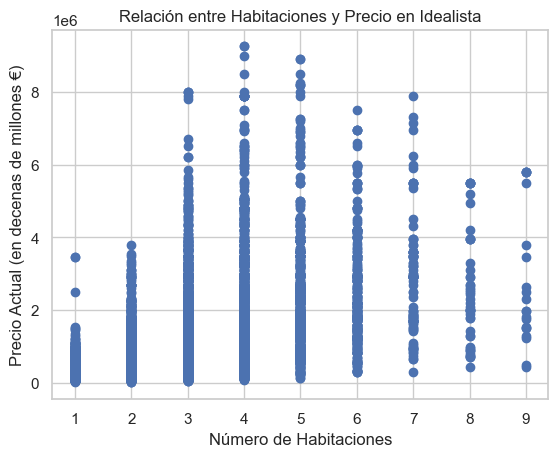

In [66]:

plt.scatter(x='habitaciones', y='PrecioActual', data=df)

# Título para el eje X
plt.xlabel('Número de Habitaciones')
# Título para el eje Y
plt.ylabel('Precio Actual (en decenas de millones €)')
# Título principal del gráfico
plt.title('Relación entre Habitaciones y Precio en Idealista')

# Para que se visualice correctamente
plt.show()


FUMADITA DE SERGIO

In [67]:
from category_encoders import TargetEncoder

# Ensure your target is numeric
df["PrecioActual"] = pd.to_numeric(df["PrecioActual"], errors="coerce")

# Initialize
encoder = TargetEncoder(cols=['zona'])

# Simple fit_transform
# X = df['zona'], y = df['PrecioActual']
df['zona_codificada'] = encoder.fit_transform(df['zona'], df['PrecioActual']);


In [68]:
zona_codificada = df.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').abs().sort_values(ascending=False)
print(zona_codificada)

zona_codificada    0.547699
habitaciones       0.515860
PrecioAnterior     0.137642
metros             0.120941
baños              0.054625
Name: PrecioActual, dtype: float64


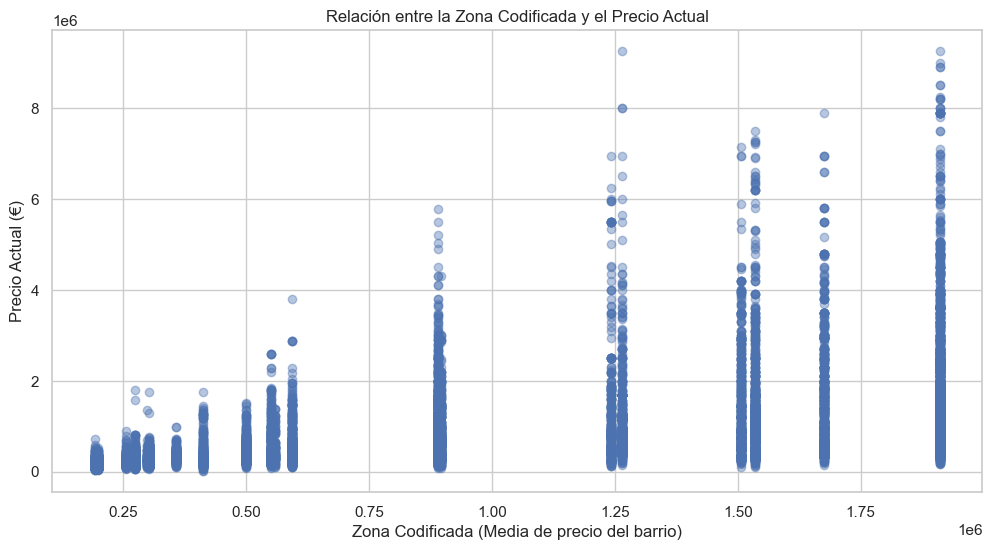

In [69]:


# Hacemos el gráfico un poco más ancho
plt.figure(figsize=(12, 6))

# Dibujamos los puntos con algo de transparencia (alpha=0.4) para ver dónde hay más pisos
plt.scatter(x='zona_codificada', y='PrecioActual', data=df, alpha=0.4)

plt.title('Relación entre la Zona Codificada y el Precio Actual')
plt.xlabel('Zona Codificada (Media de precio del barrio)')
plt.ylabel('Precio Actual (€)')

plt.show()

In [70]:
#print(df['zona_codificada'], df['zona'])
df[['zona', 'zona_codificada']].drop_duplicates().sort_values(by='zona_codificada', ascending=False)

,zona,zona_codificada
6,barrio-de-salamanca,1.911650e+06
11,chamartin,1.675393e+06
9,chamberi,1.535169e+06
8,moncloa,1.507497e+06
19,retiro,1.263978e+06
36,hortaleza,1.242987e+06
18,fuencarral,8.957365e+05
2,centro,8.904803e+05
4,tetuan,5.938363e+05
73,barajas,5.588428e+05


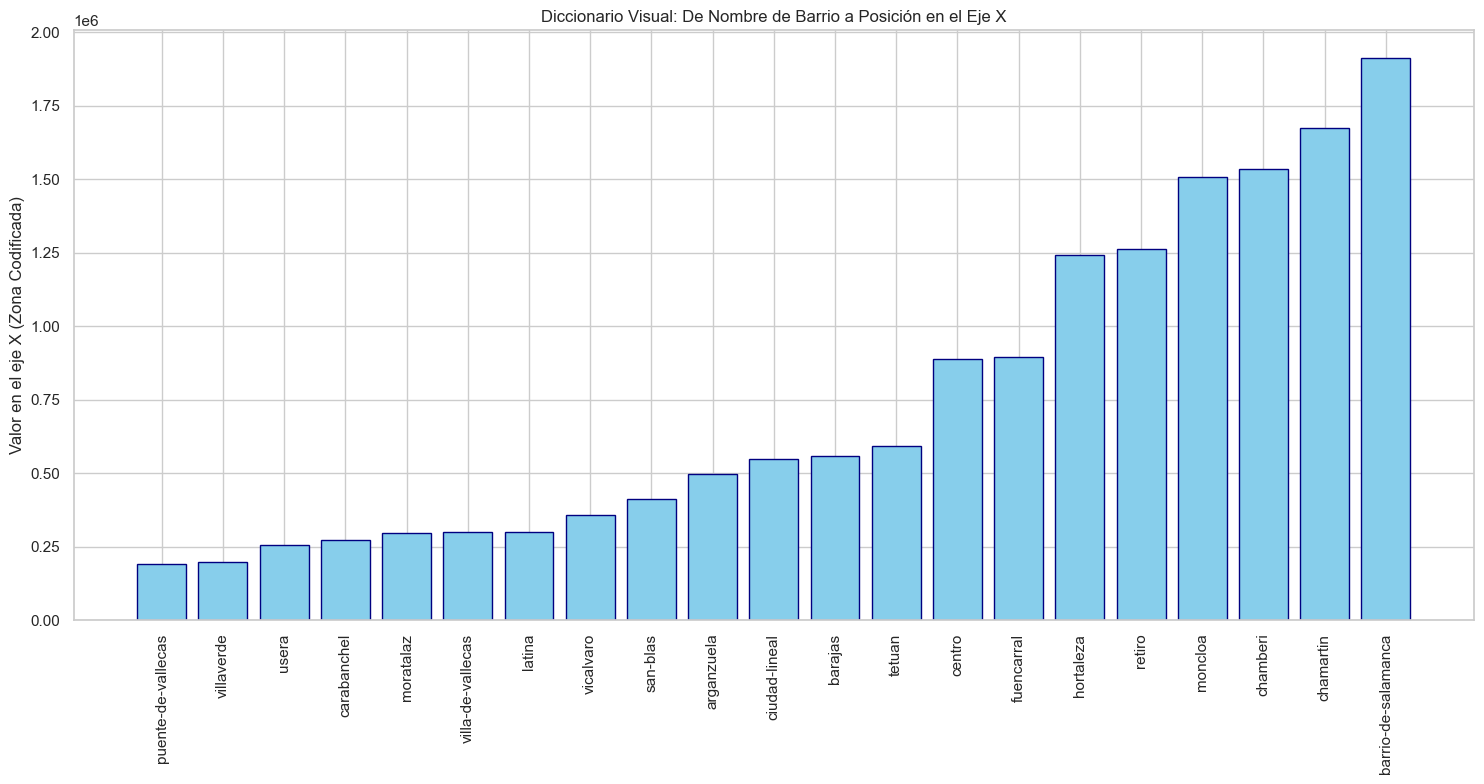

In [71]:
import matplotlib.pyplot as plt

# 1. Extraemos los valores únicos de zona y su código, ordenados de menor a mayor
mapeo_completo = df[['zona', 'zona_codificada']].drop_duplicates().sort_values(by='zona_codificada')

# 2. Creamos un gráfico de barras
plt.figure(figsize=(15, 8))
plt.bar(mapeo_completo['zona'], mapeo_completo['zona_codificada'], color='skyblue', edgecolor='navy')

# 3. Configuramos los ejes
plt.xticks(rotation=90) # Giramos los nombres 90 grados para que salgan TODOS
plt.ylabel('Valor en el eje X (Zona Codificada)')
plt.title('Diccionario Visual: De Nombre de Barrio a Posición en el Eje X')

plt.tight_layout()
plt.show()

VARIABLE PRECIO ANTERIOR VS VARIABLE OBJETIVO


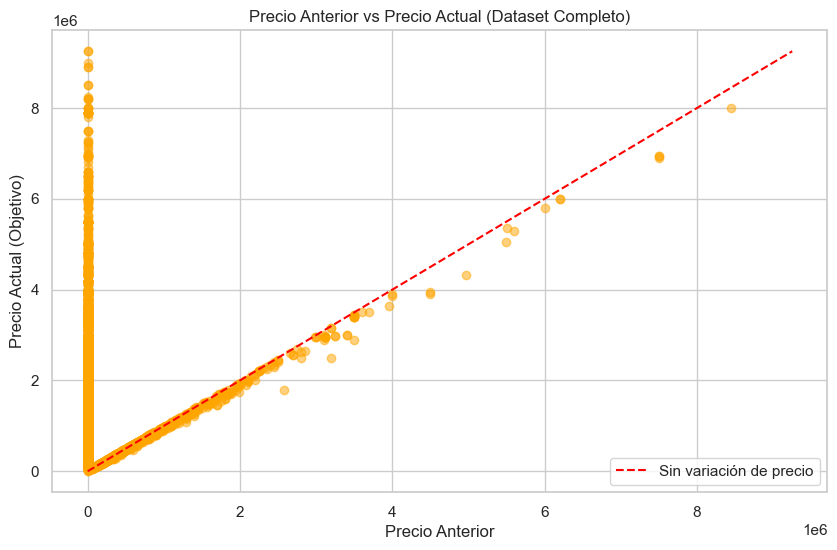

In [72]:
import matplotlib.pyplot as plt

# Crear la figura con un buen tamaño
plt.figure(figsize=(10, 6))

# Dibujar todos los datos sin filtrar (alpha=0.5 añade transparencia)
plt.scatter(x=df['PrecioAnterior'], y=df['PrecioActual'], alpha=0.5, color='orange')

# Trazar una línea roja diagonal de referencia (PrecioAnterior == PrecioActual)
max_val = max(df['PrecioAnterior'].max(), df['PrecioActual'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Sin variación de precio')

# Títulos y etiquetas
plt.xlabel('Precio Anterior')
plt.ylabel('Precio Actual (Objetivo)')
plt.title('Precio Anterior vs Precio Actual (Dataset Completo)')
plt.legend()

# Mostrar la gráfica
plt.show()

el 95% de los pisos, el PrecioAnterior es exactamente igual al PrecioActual (porque nunca han bajado de precio).
i metes PrecioAnterior como una variable más (X) para que tu modelo adivine el PrecioActual (Y), el modelo se volverá "vago". Se dará cuenta de que la forma más fácil de acertar es simplemente copiar el valor de PrecioAnterior

eliminar pisos con precio 0 o null o nan y volver a ver la correlacion

In [73]:
print(f"Filas antes de limpiar: {len(df)}")

# Nos aseguramos de que ambas columnas sean tratadas como números.
# Si hay algún texto raro o vacío, se convertirá en NaN automáticamente.
df['PrecioActual'] = pd.to_numeric(df['PrecioActual'], errors='coerce')
df['PrecioAnterior'] = pd.to_numeric(df['PrecioAnterior'], errors='coerce')

# Eliminamos cualquier fila que tenga un NaN en alguna de estas dos columnas
df = df.dropna(subset=['PrecioActual', 'PrecioAnterior'])

# Nos quedamos estrictamente con los pisos que cuesten más de 0€
# (esto elimina los 0 y también posibles precios negativos si hubiera errores)
df = df[(df['PrecioActual'] > 0) & (df['PrecioAnterior'] > 0)]

print(f"Filas después de limpiar: {len(df)}")
print("-" * 50)



Filas antes de limpiar: 11396
Filas después de limpiar: 1077
--------------------------------------------------


In [76]:
#Calculamos la correlación de todas las numéricas frente al PrecioActual
correlaciones = df.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

print("Nuevas correlaciones con PrecioActual:")
print(correlaciones)

import pandas as pd

# 1. Convertir a numérico y forzar que los textos raros se vuelvan NaN
df['PrecioActual'] = pd.to_numeric(df['PrecioActual'], errors='coerce')
df['PrecioAnterior'] = pd.to_numeric(df['PrecioAnterior'], errors='coerce')

# 2. Eliminar nulos y quedarnos solo con precios mayores a 0
df_limpio = df.dropna(subset=['PrecioActual', 'PrecioAnterior'])
df_limpio = df_limpio[(df_limpio['PrecioActual'] > 0) & (df_limpio['PrecioAnterior'] > 0)]

# 3. Calcular la correlación y mostrarla por pantalla
correlacion_numerica = df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

print(correlacion_numerica)

Nuevas correlaciones con PrecioActual:
PrecioAnterior     0.998599
metros             0.755790
habitaciones       0.510905
zona_codificada    0.502315
baños              0.036930
Name: PrecioActual, dtype: float64
PrecioAnterior     0.998599
metros             0.755790
habitaciones       0.510905
zona_codificada    0.502315
baños              0.036930
Name: PrecioActual, dtype: float64


VOLVER A SACAR GRAFICO PRECIO ANTEIROR VS PRECIO ACTUAL

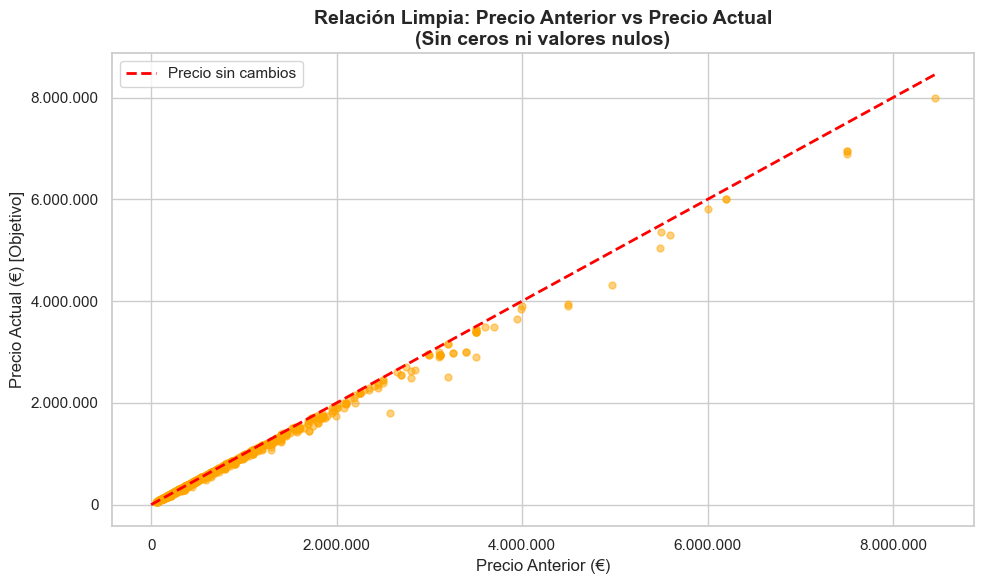

In [78]:
#Configurar el tamaño y estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Dibujar los datos (usando el df que ya tienes limpio de la celda anterior)
plt.scatter(x=df['PrecioAnterior'], y=df['PrecioActual'], alpha=0.5, color='orange', s=25)

# 3. Trazar la línea roja diagonal (referencia de "no cambio")
# Usamos el máximo de ambos para que la línea cruce perfectamente
max_val = max(df['PrecioAnterior'].max(), df['PrecioActual'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Precio sin cambios')

# 4. Formatear los ejes para que se lean bien los euros (evitar notación científica)
formatter = ticker.FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", "."))
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# 5. Títulos y etiquetas
plt.xlabel('Precio Anterior (€)', fontsize=12)
plt.ylabel('Precio Actual (€) [Objetivo]', fontsize=12)
plt.title('Relación Limpia: Precio Anterior vs Precio Actual\n(Sin ceros ni valores nulos)', fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()